# Report (Module\_A) B+ Tree vs. Brute Force

Group: Aarsh, Abhinav, Jaskirat, Karan, Romit

This report is a mix of [bench.ipynb](./bench.ipynb) (Benchmarking results), and [visualize.ipynb](./visualize.ipynb) (GraphViz Visualizations)

Reference for B+ Tree
- https://www.programiz.com/dsa/b-plus-tree
- http://youtube.com/playlist?list=PLzzVuDSjP25QT0H605qxlcmMy_GBTHi8X&si=zLHuzpCyUDTMtZ39

## Importing database, visualize, and benchmarking functionalities

In [1]:
from database.db_manager import DatabaseManager
from database.visualize import visualize
from database.benchmarking.bench import PerformanceAnalyzer
import matplotlib.pyplot as plt

## Walking though the DatabaseManager API

In [2]:
dbm = DatabaseManager()
db = dbm.create_database(db_name='first_db')

In [3]:
try:
    dbm.create_database(db_name='first_db')
except Exception as e:
    print(e)

Database with name first_db already exists


In [4]:
db2 = dbm.create_database(db_name="second_db")
db2_tbl1 = db2.create_table('table_one',['first','second','thrid'],primary_key='first',indexer='brute')

db2.list_tables()

['table_one']

In [5]:
dbm.list_databases()

['first_db', 'second_db']

In [6]:
dbm.delete_database('second_db')

True

In [7]:
dbm.list_databases()

['first_db']

In [ ]:
students = db.create_table(name='students',columns=['rollnumber','name','programme','department','joining_year'],primary_key='rollnumber',indexer='brute')

instructors = db.create_table(name='instructors',columns=['instructor_id','name','department','salary'],primary_key='instructor_id',indexer='bplus',degree=5)


Creating another table with same name should lead to an error

In [ ]:
try:
    instructors = db.create_table(name='instructors',columns=['instructor_id','name','department','salary'],primary_key='instructor_id',indexer='bplus',degree=5)
except Exception as e:
    print(e)

Table 'instructors' already exists


Listing Tables

In [ ]:
db.list_tables()

['students', 'instructors']

Selecting a Table

In [ ]:
students2 = db.get_table('students')

In [71]:
students == students2

True

Dropping a Table

In [ ]:
db.drop_table('instructors')
db.list_tables()

['students']

## Table API


In [ ]:
students = db.get_table('students')

Inserting a row

In [74]:
students.insert_row(
    row=dict(
        zip(
            ["rollnumber", "name", "programme", "department", "joining_year"],
            [23110146, "Jaskirat", "B.Tech.", "Computer Science", 2023],
        )
    )
)

Inserting another row with same primary key results in an error

In [75]:
try:
    students.insert_row(
        row=dict(
            zip(
                ["rollnumber", "name", "programme", "department", "joining_year"],
                [23110146, "BLAH", "BLAH", "BLAH", 0],
            )
        )
    )
except Exception as e:
    print(e)

Duplicate primary key: 23110146


Inserting multiple rows

In [76]:
rows = [
    [23110003, "Aarsh", "B.Tech.", "Computer Science", 2023],
    [25110006, "Abhinav", "B.Tech.", "Electrical Engineering", 2025],
    [27110146, "Romit", "B.Tech.", "Future Engineering", 2027],
]
for row in rows:
    students.insert_row(
        row=dict(
            zip(
                ["rollnumber", "name", "programme", "department", "joining_year"],
                row,
            )
        )
    )

Selecting all rows

In [77]:
students.select_all()

[{'rollnumber': 23110146,
  'name': 'Jaskirat',
  'programme': 'B.Tech.',
  'department': 'Computer Science',
  'joining_year': 2023},
 {'rollnumber': 23110003,
  'name': 'Aarsh',
  'programme': 'B.Tech.',
  'department': 'Computer Science',
  'joining_year': 2023},
 {'rollnumber': 25110006,
  'name': 'Abhinav',
  'programme': 'B.Tech.',
  'department': 'Electrical Engineering',
  'joining_year': 2025},
 {'rollnumber': 27110146,
  'name': 'Romit',
  'programme': 'B.Tech.',
  'department': 'Future Engineering',
  'joining_year': 2027}]

Selecting one row by primary key

In [78]:
students.select(23110146)

{'rollnumber': 23110146,
 'name': 'Jaskirat',
 'programme': 'B.Tech.',
 'department': 'Computer Science',
 'joining_year': 2023}

Deleting a row by primary key (False -> not found | True -> deleted)

In [79]:
students.delete_row(23110001)

False

In [80]:
students.delete_row(23110146)

True

Updating a row

In [81]:
students.update_row(
    25110006,
    dict(
        zip(
            ["rollnumber", "name", "programme", "department", "joining_year"],
            [25110006, "Abhinav","M.Tech","Anime Engineering", 2025],
        )
    ),
)

True

In [82]:
students.select_all()

[{'rollnumber': 23110003,
  'name': 'Aarsh',
  'programme': 'B.Tech.',
  'department': 'Computer Science',
  'joining_year': 2023},
 {'rollnumber': 25110006,
  'name': 'Abhinav',
  'programme': 'M.Tech',
  'department': 'Anime Engineering',
  'joining_year': 2025},
 {'rollnumber': 27110146,
  'name': 'Romit',
  'programme': 'B.Tech.',
  'department': 'Future Engineering',
  'joining_year': 2027}]

Select Range, Eg. students joined after 2023

In [83]:
students.select_range(start_key=25000000, end_key=1e9)

[{'rollnumber': 25110006,
  'name': 'Abhinav',
  'programme': 'M.Tech',
  'department': 'Anime Engineering',
  'joining_year': 2025},
 {'rollnumber': 27110146,
  'name': 'Romit',
  'programme': 'B.Tech.',
  'department': 'Future Engineering',
  'joining_year': 2027}]

## Visualizations

We will insert/delete data in a specific manner to trigger splits/merges. So that it will be easier to visualize

In [ ]:
tbl = db.create_table('main',['id','name','marks'],'id','bplus')

In [106]:
data = [
    {"id": 10, "name": "Jaskirat", "marks": 25},
    {"id": 20, "name": "Karan", "marks": 30},
    {"id": 30, "name": "Aarsh", "marks": 35},
    {"id": 40, "name": "Romit", "marks": 40},
    {"id": 50, "name": "Abhinav", "marks": 45},
    {"id": 60, "name": "Tariksaj", "marks": 50},
    {"id": 70, "name": "Narak", "marks": 55},
    {"id": 80, "name": "Hsraa", "marks": 60},
    {"id": 15, "name": "Navihba", "marks": 22},
    {"id": 25, "name": "Rajak", "marks": 28},
]

Inserting first three rows doesn't cause a split

After inserting 3 rows (no split yet):


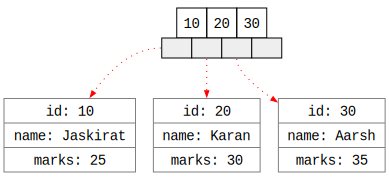

In [107]:
for row in data[:3]:
    tbl.insert_row(row)

print("After inserting 3 rows (no split yet):")
visualize(tbl.tree.root, degree=4)

Inserting the fourth row, causes a split

After inserting id=40 :


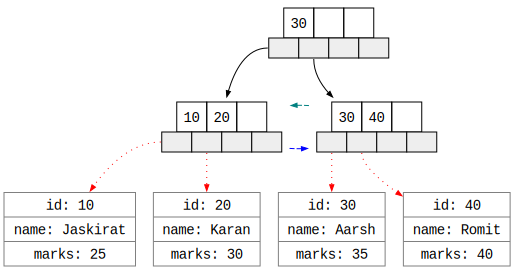

In [108]:
tbl.insert_row(data[3])

print("After inserting id=40 :")
visualize(tbl.tree.root, degree=4)

We insert the remaining rows, potentially causing many splits

After inserting all 10 rows:


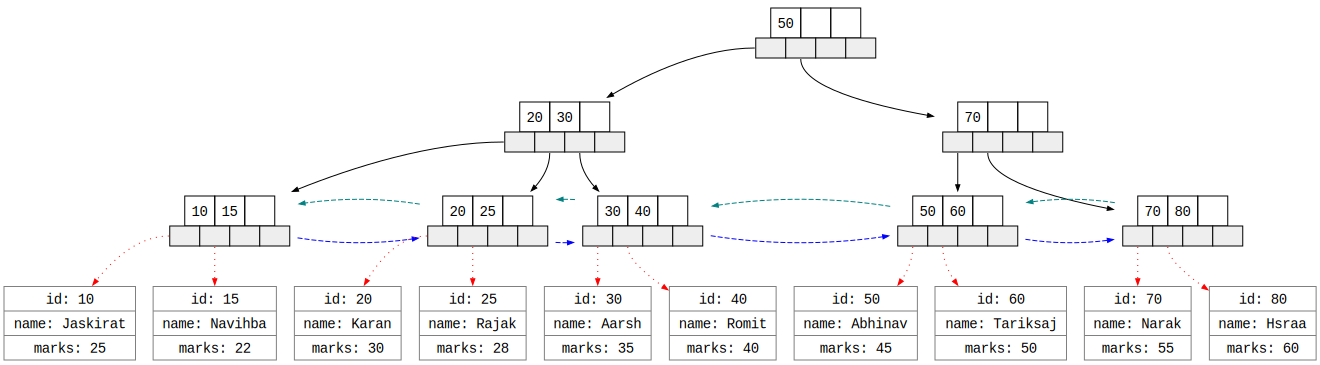

In [109]:
for row in data[4:]:
    tbl.insert_row(row)

print("After inserting all 10 rows:")
visualize(tbl.tree.root, degree=4)

Deleting the key 50 doesn't cause a underflow, however it does appear in internal nodes

After deleting id=50:


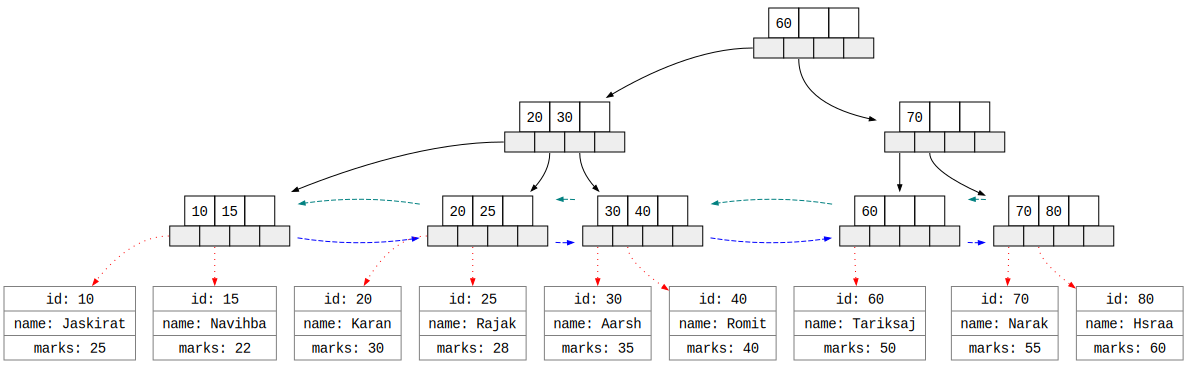

In [110]:
tbl.delete_row(50)

print("After deleting id=50:")
visualize(tbl.tree.root, degree=4)

Deleting 60 causes a underflow, triggering a borrow from neighbor

After deleting id=60:


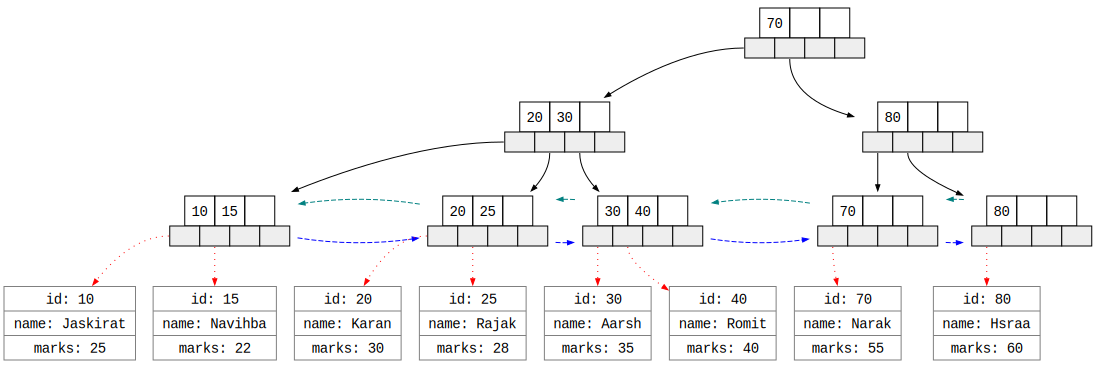

In [111]:
tbl.delete_row(60)

print("After deleting id=60:")
visualize(tbl.tree.root, degree=4)

Deleting 70 and 80:


After deleting id=70, 80:


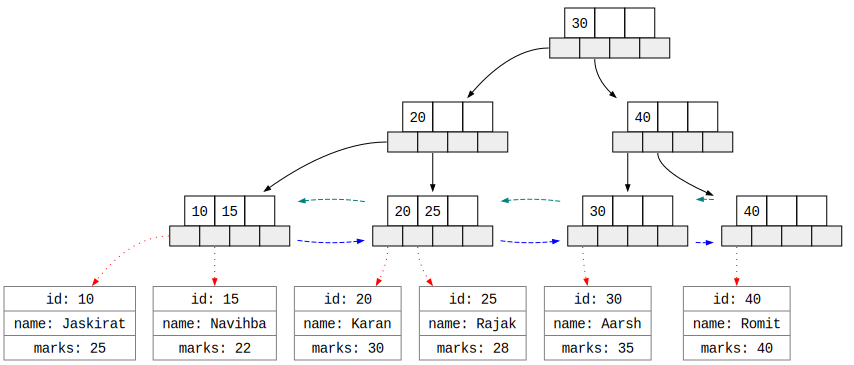

In [112]:
tbl.delete_row(70)
tbl.delete_row(80)

print("After deleting id=70, 80:")
visualize(tbl.tree.root, degree=4)

Deleting a separator key which has children on left and right in non-leaf (internal) node.

This also triggers the height shrinkage

After deleting id=40:


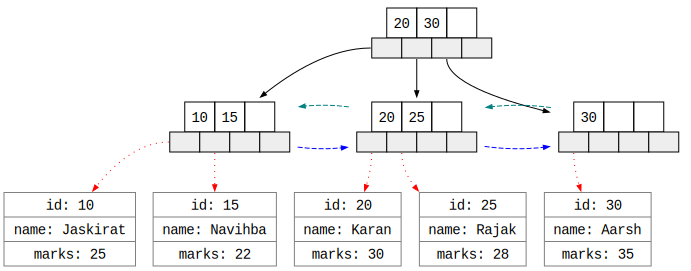

In [113]:
tbl.delete_row(40)

print("After deleting id=40:")
visualize(tbl.tree.root, degree=4)

Deleting more rows

After deleting id=30, 25, 20:


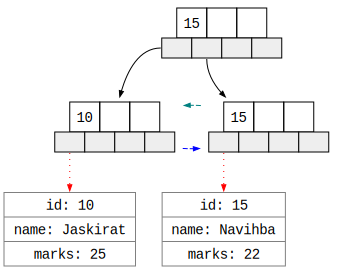

In [114]:
tbl.delete_row(30)
tbl.delete_row(25)
tbl.delete_row(20)

print("After deleting id=30, 25, 20:")
visualize(tbl.tree.root, degree=4)

Final tree state:

Remaining rows: [{'id': 10, 'name': 'Jaskirat', 'marks': 25}, {'id': 15, 'name': 'Navihba', 'marks': 22}]


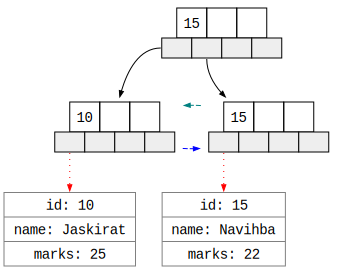

In [115]:
print("Remaining rows:", tbl.tree.get_all())
visualize(tbl.tree.root, degree=4)

## Benchmarking

In [ ]:
analyzer = PerformanceAnalyzer(result_folder='benchmarking_results')

Running bench_scale_size
Running bench_varying_degree
Running bench_key_insertion_order
Running bench_incremental_insert
Running bench_bulk_delete
Running bench_range_queries
Running bench_mixed_load
Running bench_memory_usage


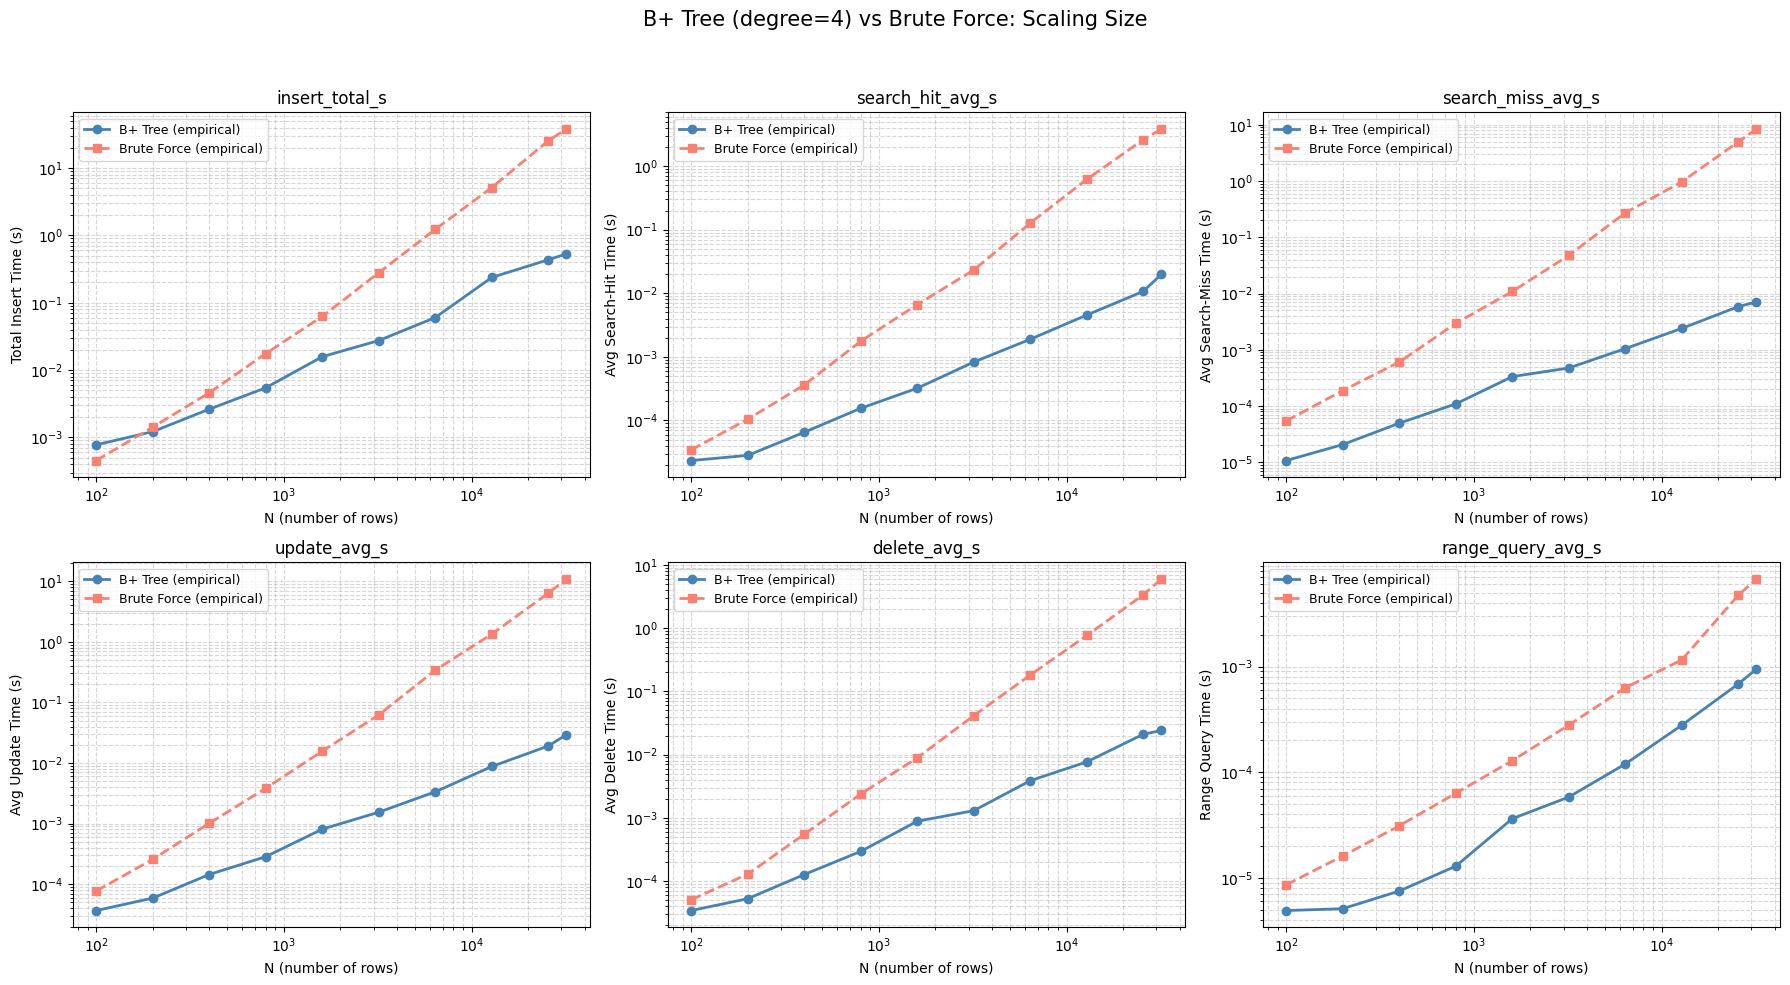

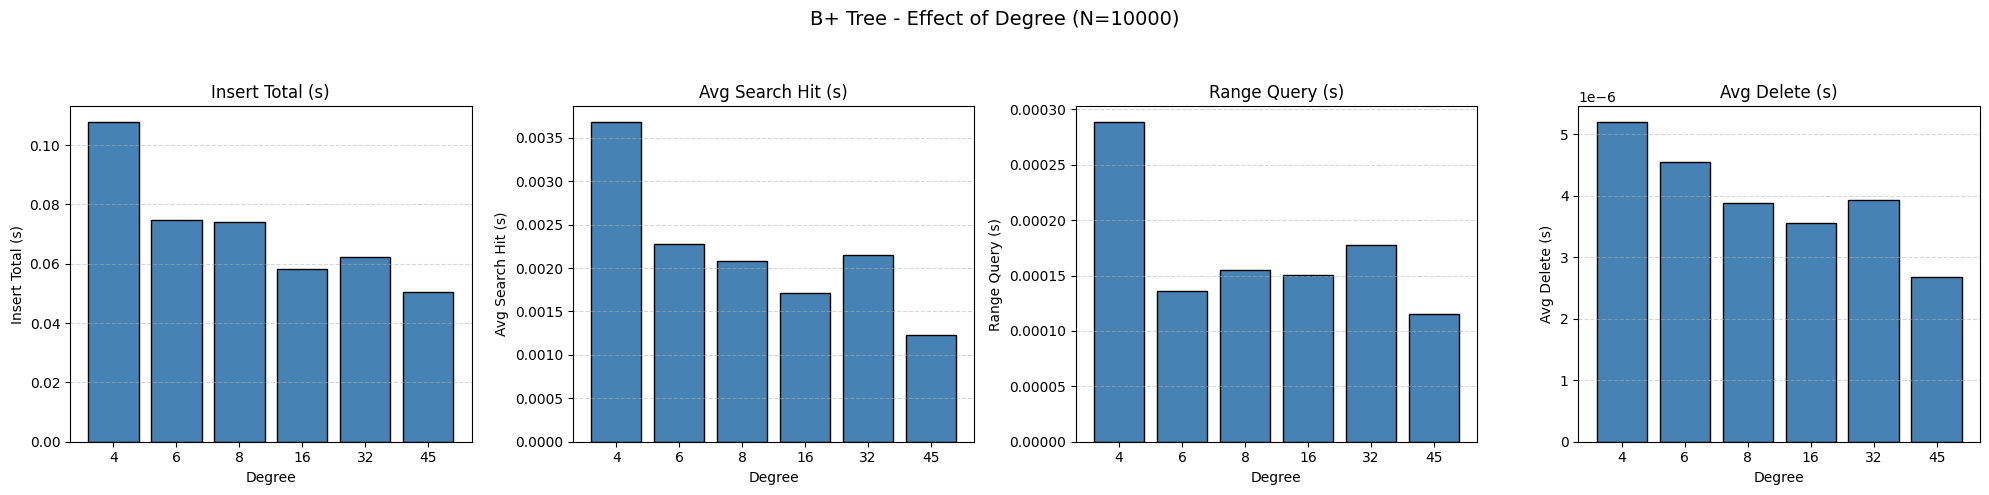

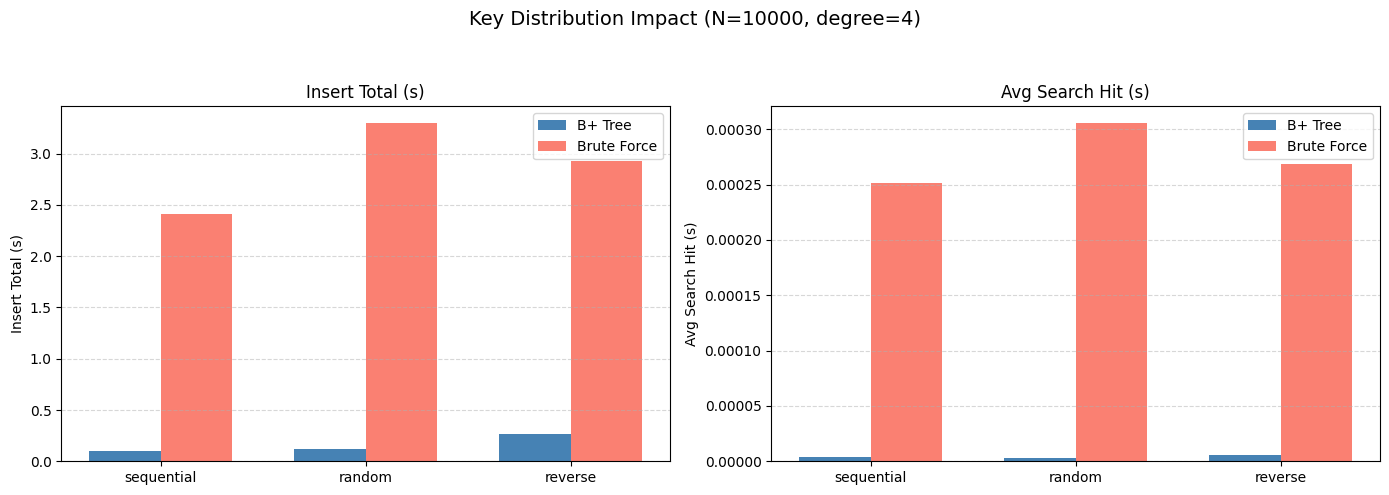

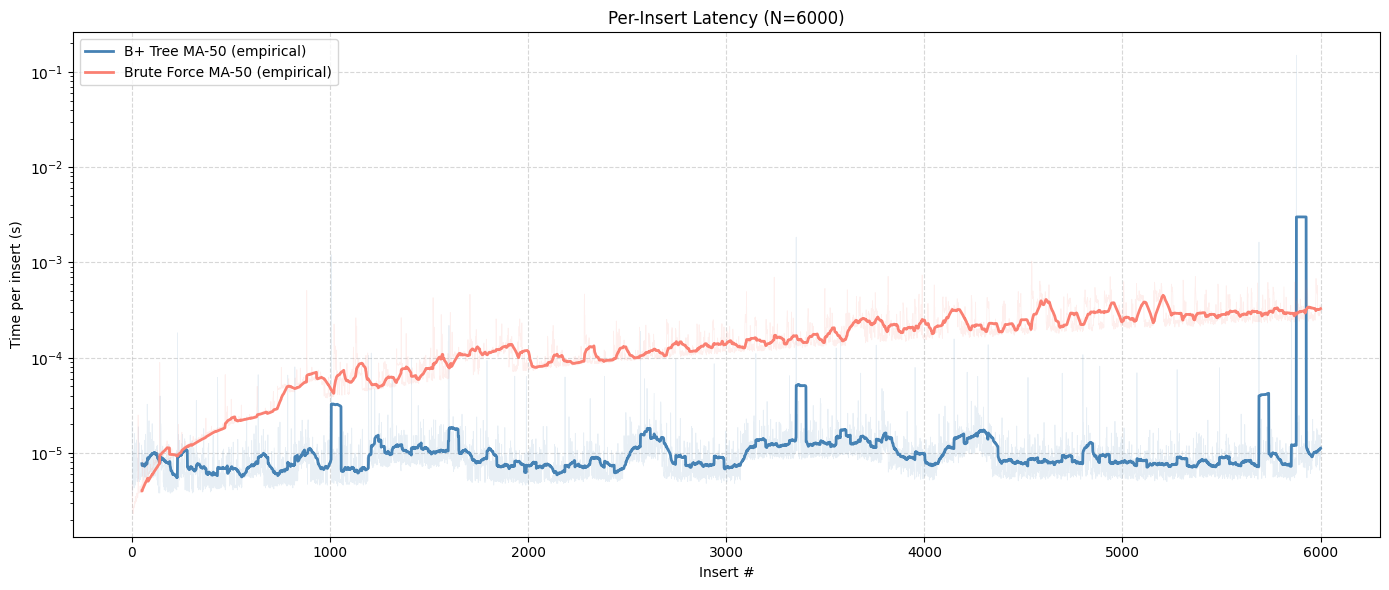

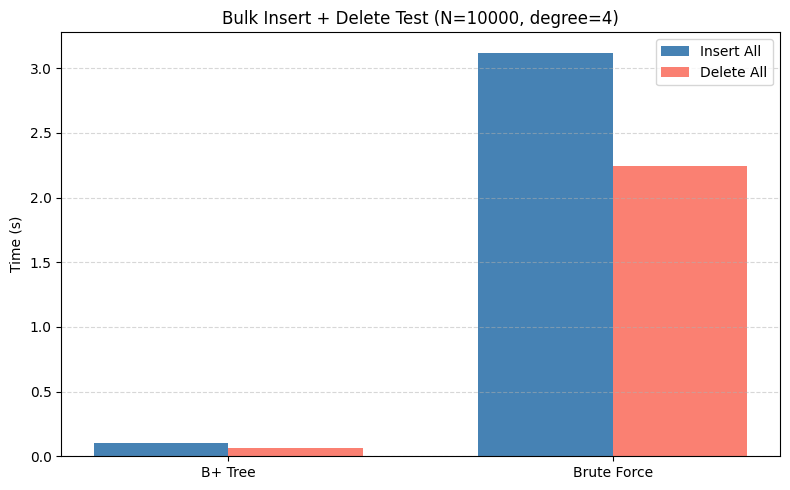

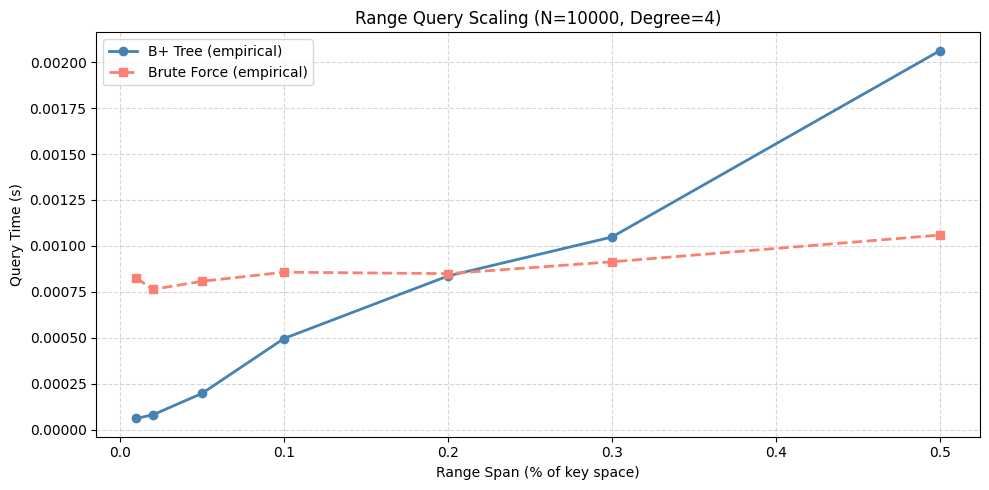

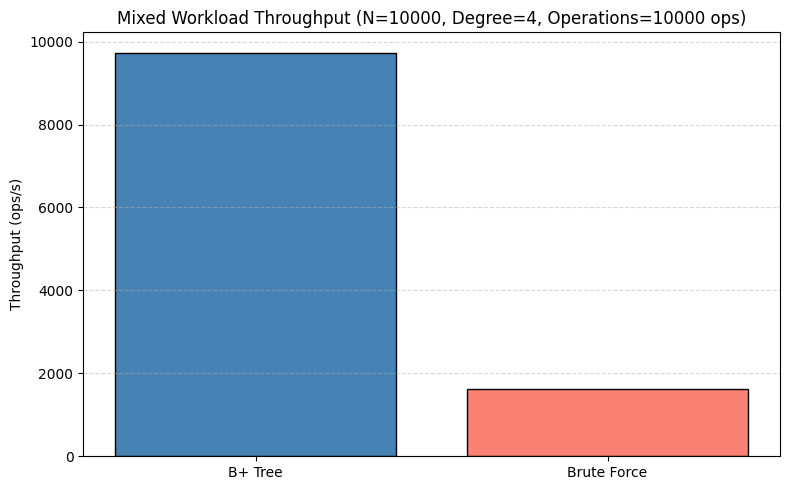

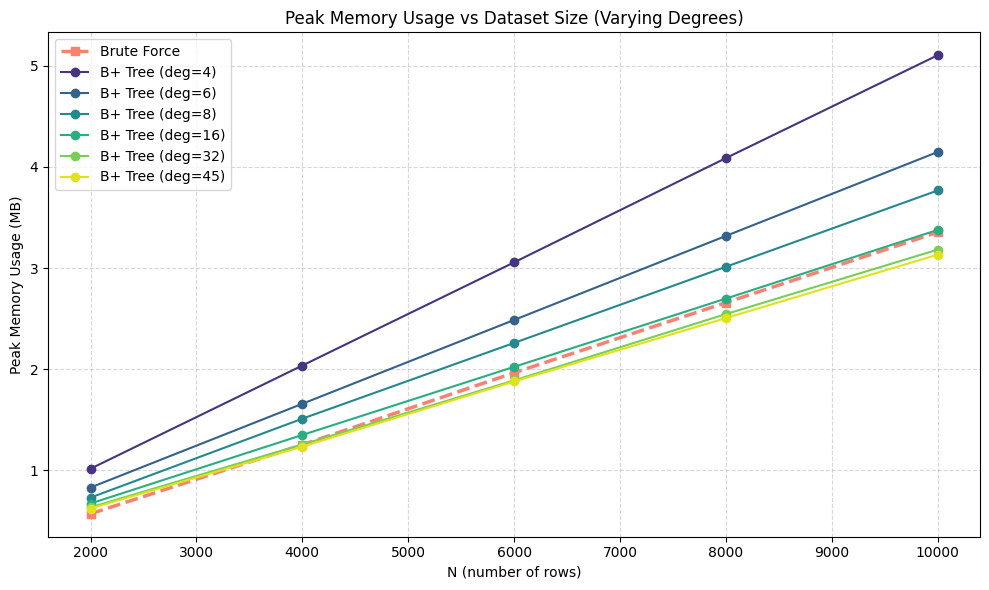

In [ ]:
figs = analyzer.run()

bench_scale_size
 Measure insert_all, search_hit, search_miss, update, delete and range query time for brutefoce and b+tree implementation for varying number of rows, but given a fixed degree. 



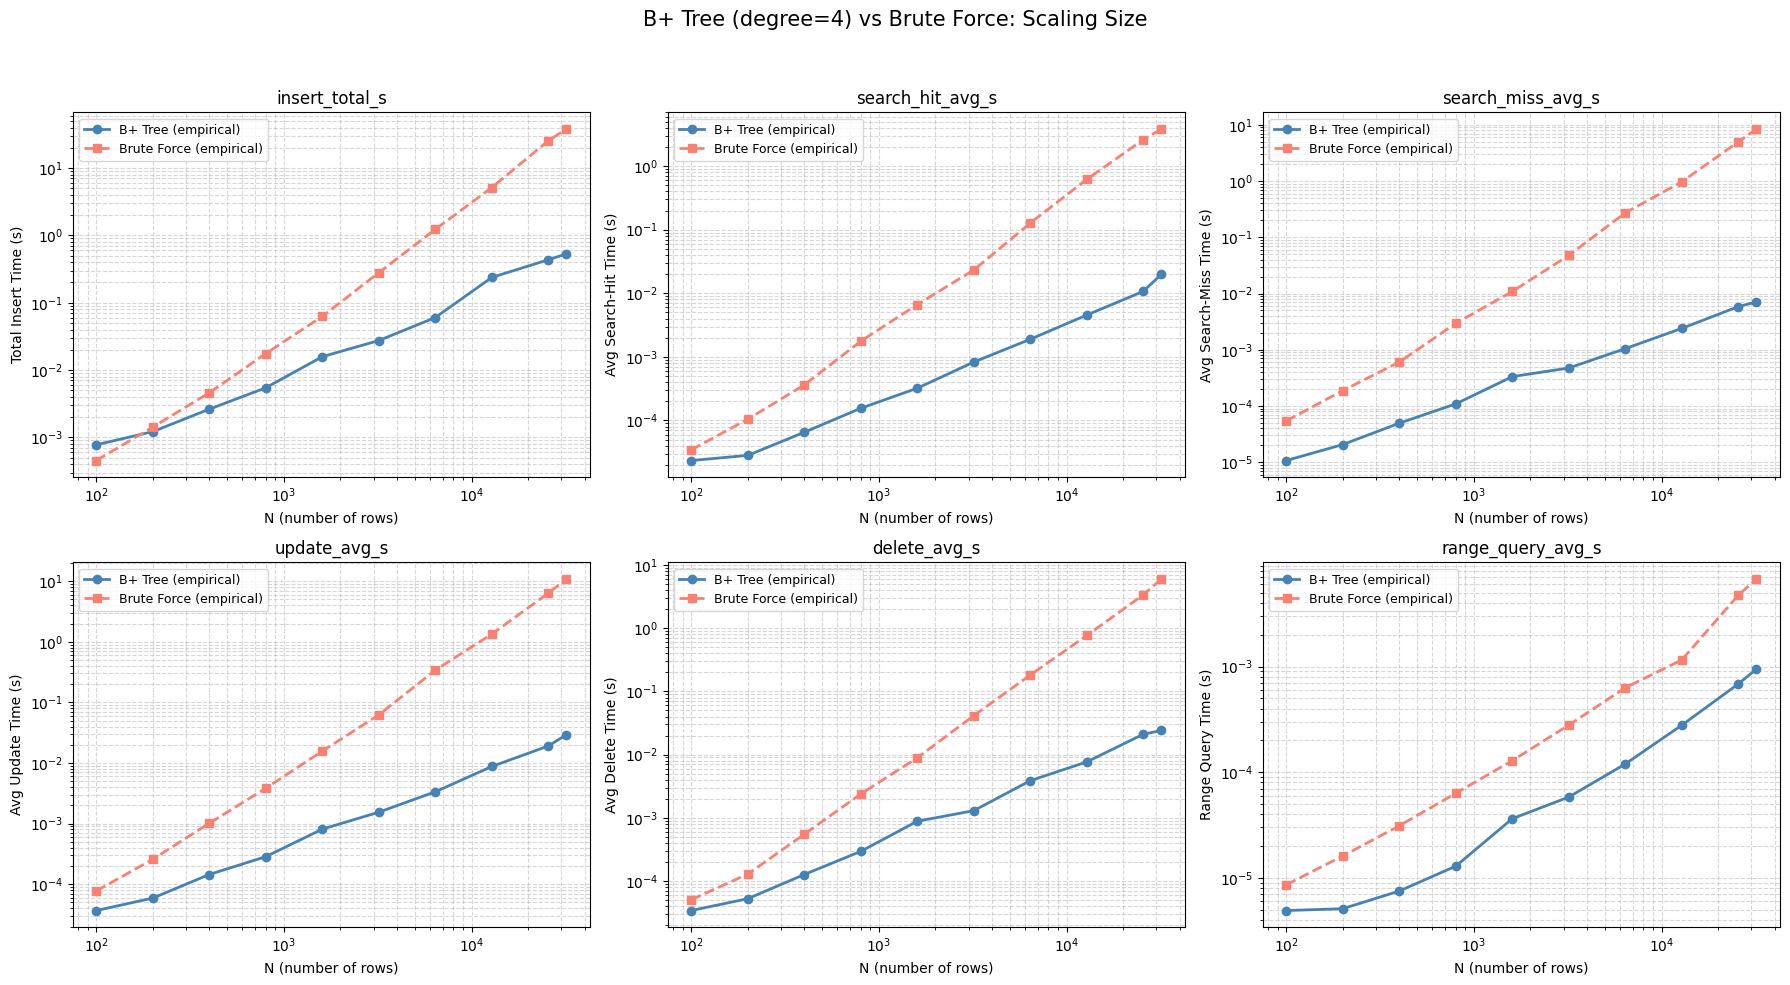

bench_varying_degree
 Measuring bulk insert, avg search hit, avg range query, and avg delete time for a fixed numbe of rows, but varying the degree 



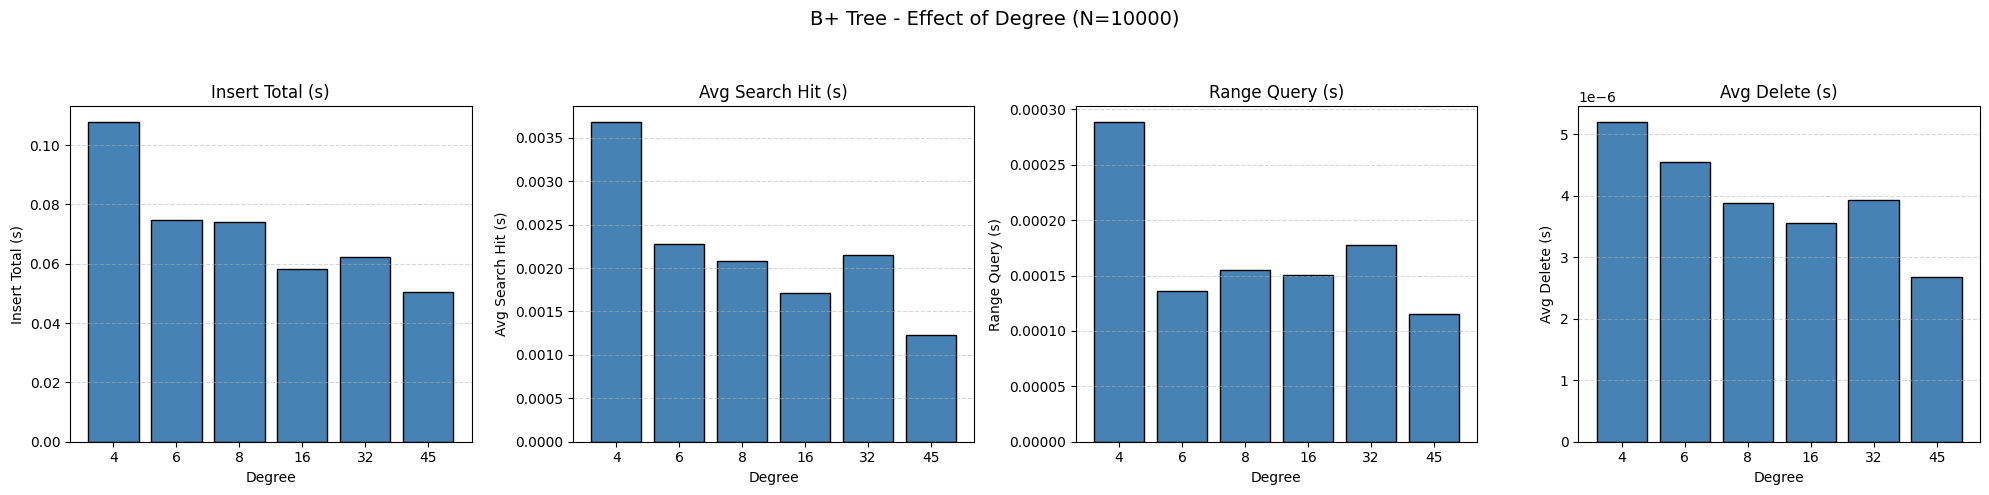

bench_key_insertion_order
compare insert + search performance for sequential, random and reverse ordered key insertion for both bplus and brute



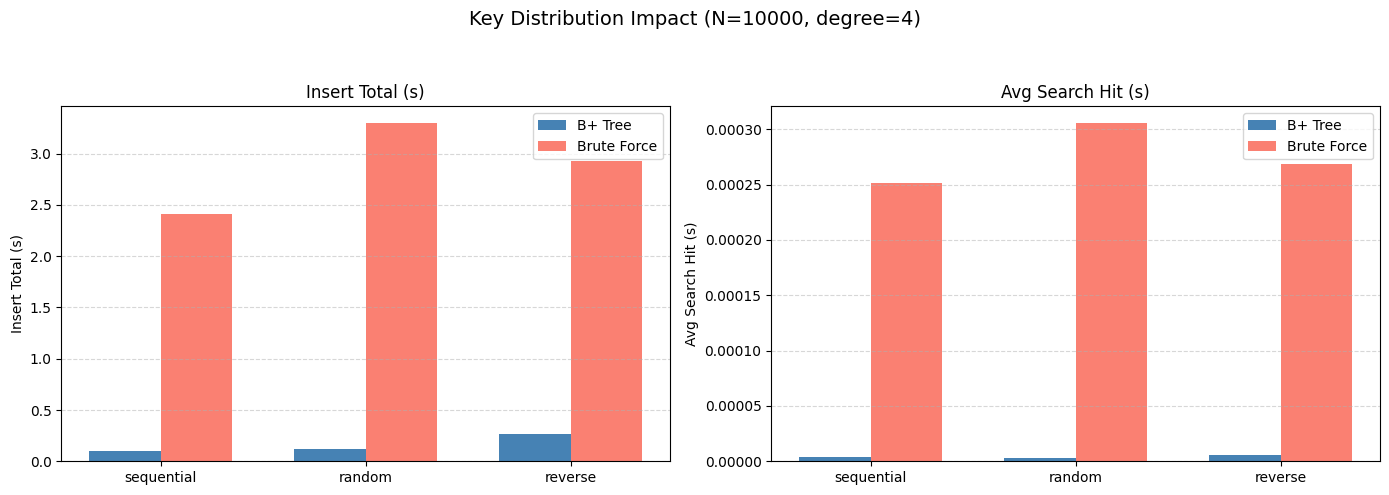

bench_incremental_insert
 insert keys one by one, and see per insert latency. should show small spike in B+ tree, if node split happnes. 



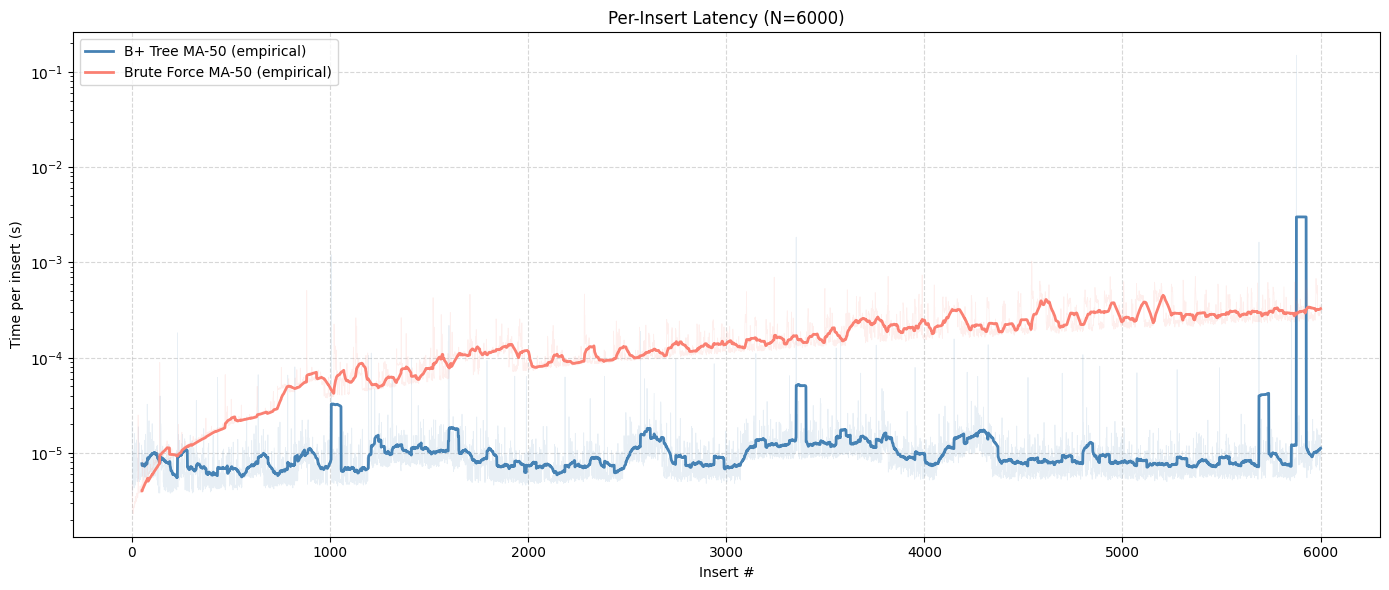

bench_bulk_delete
 insert a large number of rows then delete it in random order to measure bulk delete performance. triggers heavy underflow/merge cascades in the B+ Tree. 



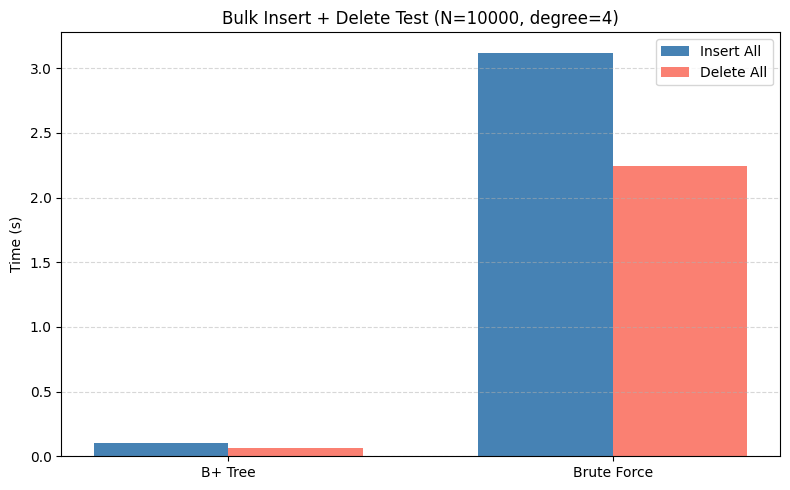

bench_range_queries
 Do a range query, vary range span from defined low% to high% of key space. And measure times. 



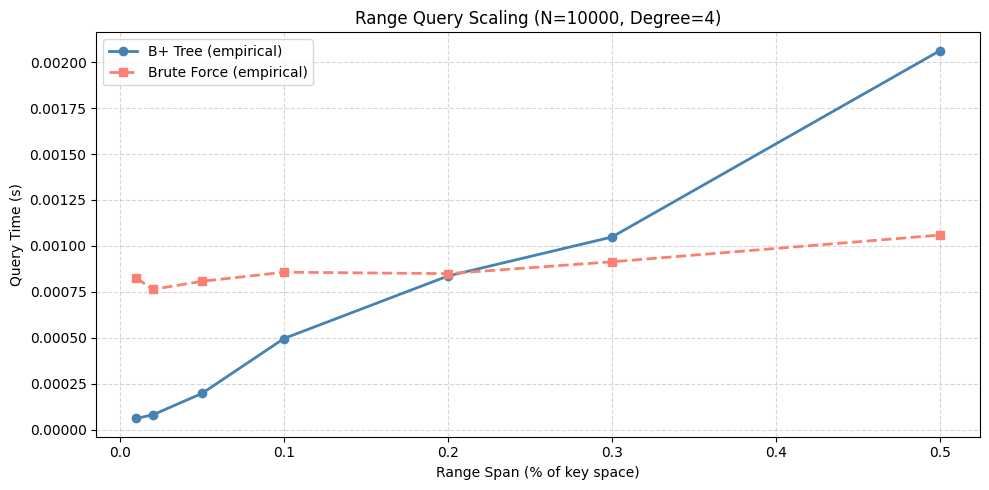

bench_mixed_load
 Measure time for 50% search, 20% insert, 15% update, 10% delete, 5% range query 



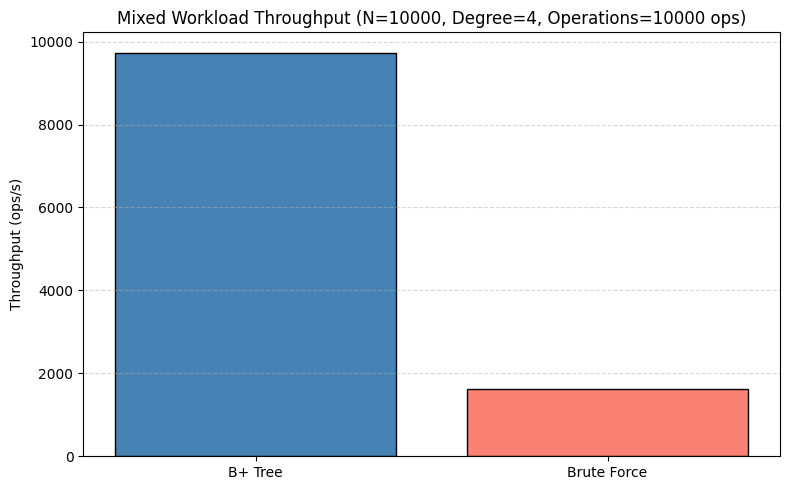

bench_memory_usage
 Measure the peak memory usage scaling with the number of rows across varying degrees. 



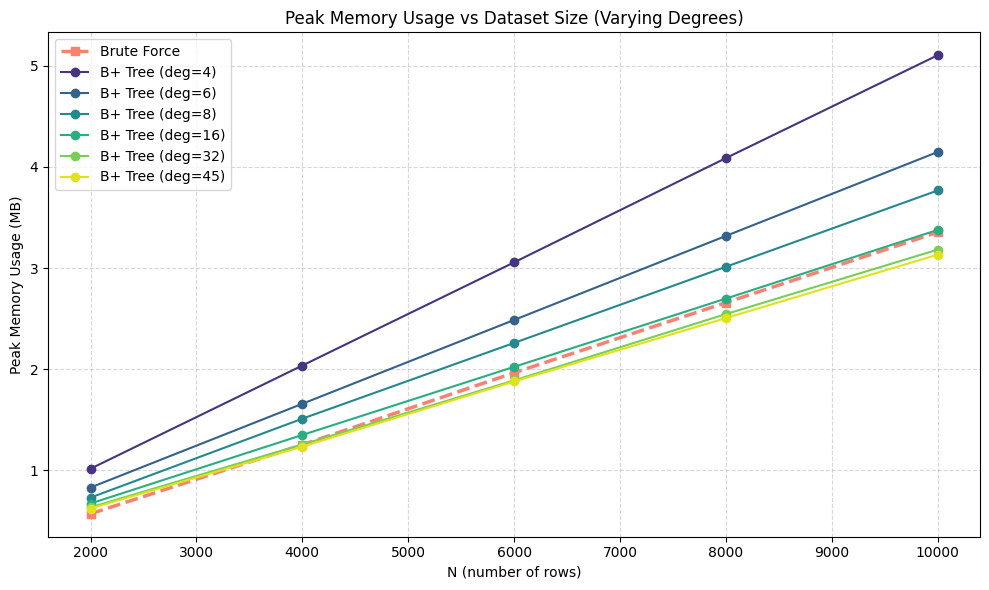

In [ ]:
for k,v in figs.items():
    print(f"{k}\n{v[0]}\n")
    plt.figure(v[1])
    plt.show()
    v[1].savefig(f'benchmarking_results/{k}.png')